---
title: "Layer-wise inspection of a Gaussianization flow"
short_title: "04 · Layer-wise inspection"
subtitle: "Push data through one layer at a time to watch Gaussianity improve, see the rotation↔marginal push-pull, and diagnose where the flow does its work"
description: >
  A trained flow is usually a black box. This notebook opens one up: it applies a
  Gaussianization flow's layers one at a time to the data, plots the pushforward
  morphing toward N(0,I), and tracks per-step diagnostics. The diagnostics reveal
  the RBIG mechanism — rotations decorrelate but raise marginal non-Gaussianity,
  marginal steps knock it down — and show that the work concentrates in the first
  layers. Includes the trick for unrolling a flowjax Scan.
---

(sec-nb-para-04)=
# 04 — Layer-wise inspection of a Gaussianization flow

We have trained, warm-started, and compared several flows, always reading just the
*final* log-likelihood. But a Gaussianization flow is a **stack** of interpretable
layers — rotations and marginal transforms — and we can watch the data become
Gaussian as it passes through them. Layer-wise inspection answers practical
questions: *Where* does the flow do its work? Are later layers earning their keep?
Is the latent actually $\mathcal{N}(0,I)$, or only in its low-order moments?

A flow's density direction maps data $x$ to latent $z$ through a composed bijection
$T = T_L \circ \cdots \circ T_1$. We simply apply the $T_k$ one at a time and run
the Part 0 [diagnostics](../00_foundations/06_gaussianity_diagnostics.ipynb) on each
intermediate.

**What you will see**

- The **pushforward morph**: data → $\mathcal{N}(0,I)$, snapshot per layer.
- The **rotation↔marginal push-pull**: rotations kill correlation but raise
  marginal kurtosis; marginal steps Gaussianize it back down.
- A diagnosis: the work concentrates **early**, and a residual kurtosis persists —
  visible only because we looked inside.
- The **`Scan`-unrolling trick** for inspecting a `gaussianization_flow`.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.datasets import make_moons

import gauss_flows as gf
from _style import SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)

X, _ = make_moons(n_samples=3000, noise=0.08, random_state=0)
X = jnp.asarray((X - X.mean(0)) / X.std(0))

## 1. The pushforward, one layer at a time

We use a greedy `fit_rbig` model — a real, well-fit Gaussianization flow whose
bijection is an `Invert`-wrapped **`Chain`**, so its layers are directly iterable
(no training needed; the same inspection applies to any trained flow, §3). The
density map $x\to z$ is the chain's forward `transform`; we apply each sub-bijection
in turn and keep the intermediate. Each RBIG layer is a pair: a `FixedRotation`
then a `MixtureGaussianCDF` marginal.

12 sub-bijections: ['FixedRotation', 'MixtureGaussianCDF', 'FixedRotation', 'MixtureGaussianCDF'] ...


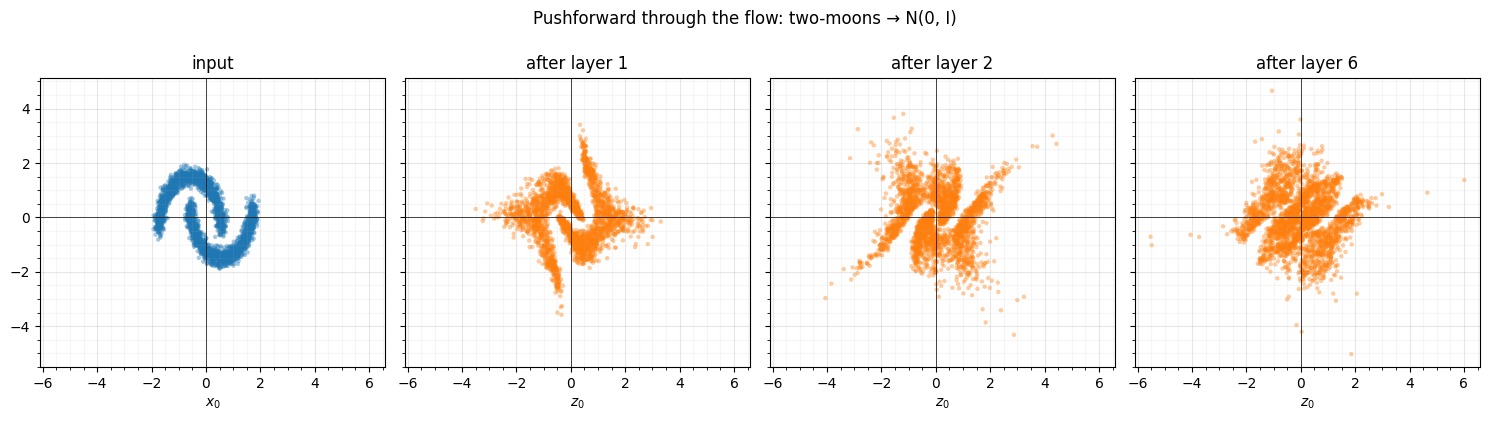

In [2]:
flow = gf.fit_rbig(X, n_layers=6, n_components=8, random_state=0)
layers = flow.bijection.bijection.bijections          # Invert -> Chain -> [rot, marg, rot, marg, ...]
kinds = [type(b).__name__ for b in layers]
print(f"{len(layers)} sub-bijections: {kinds[:4]} ...")

# Apply layers cumulatively; snapshot after each full (rotation + marginal) layer.
A = X
per_step = [np.asarray(A)]                            # after each sub-bijection
for b in layers:
    A = jax.vmap(b.transform)(A)
    per_step.append(np.asarray(A))
layer_snaps = [per_step[0]] + [per_step[i] for i in range(2, len(per_step), 2)]  # input + after each layer

show = [0, 1, 2, 6]
fig, axes = plt.subplots(1, len(show), figsize=(15, 3.7), sharex=True, sharey=True)
for ax, k in zip(axes, show):
    ax.scatter(layer_snaps[k][:, 0], layer_snaps[k][:, 1],
               color=("tab:blue" if k == 0 else "tab:orange"), **SCATTER_KW)
    ax.set(title=("input" if k == 0 else f"after layer {k}"), xlabel="$x_0$" if k == 0 else "$z_0$")
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    ax.set_aspect("equal"); style_ax(ax)
fig.suptitle("Pushforward through the flow: two-moons → N(0, I)", y=1.04)
fig.tight_layout()

By the first layer the cloud is already close to isotropic, and later layers only
polish it — the first hint that the work is front-loaded (the RBIG monotone-
reduction property {cite}`laparra2011rbig`). The scatter alone is
coarse, though; to see *what* each sub-step does we need quantitative diagnostics.

## 2. The rotation↔marginal push-pull

We run two Part 0 diagnostics after **every sub-bijection**: the off-diagonal
**correlation** (dependence) and the mean **\|excess kurtosis\|** (marginal
non-Gaussianity). Splitting by step type exposes the RBIG mechanism.

input: corr=0.443, mean|kurt|=1.041
  step  0 [rotation]: corr=0.000  kurt=1.245
  step  1 [marginal]: corr=0.013  kurt=0.014
  step  2 [rotation]: corr=0.000  kurt=0.819
  step  3 [marginal]: corr=0.001  kurt=0.190
  step  4 [rotation]: corr=0.000  kurt=0.781
  step  5 [marginal]: corr=0.016  kurt=0.058
  step  6 [rotation]: corr=0.000  kurt=0.092
  step  7 [marginal]: corr=0.007  kurt=0.233
  step  8 [rotation]: corr=0.000  kurt=0.219
  step  9 [marginal]: corr=0.001  kurt=0.335
  step 10 [rotation]: corr=0.000  kurt=0.748
  step 11 [marginal]: corr=0.002  kurt=0.510


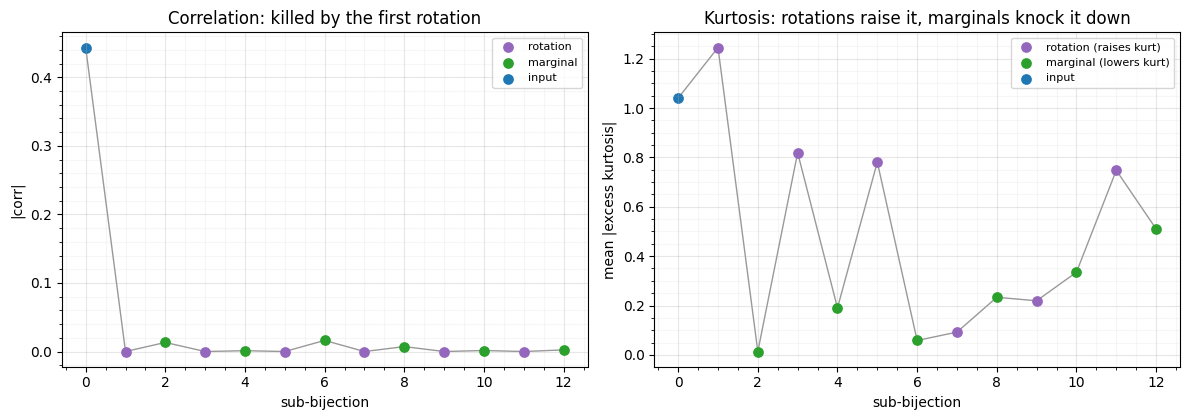

In [3]:
A = X
corr, kurt, kind = [], [], []
for b in layers:
    A = jax.vmap(b.transform)(A); Z = np.asarray(A)
    corr.append(abs(np.corrcoef(Z.T)[0, 1]))
    kurt.append(float(np.abs(stats.kurtosis(Z, axis=0)).mean()))
    kind.append("rotation" if type(b).__name__ == "FixedRotation" else "marginal")

x0 = np.abs(np.corrcoef(np.asarray(X).T)[0, 1])
k0 = float(np.abs(stats.kurtosis(np.asarray(X), axis=0)).mean())
print(f"input: corr={x0:.3f}, mean|kurt|={k0:.3f}")
for i, (c, k, t) in enumerate(zip(corr, kurt, kind)):
    print(f"  step {i:2d} [{t:8s}]: corr={c:.3f}  kurt={k:.3f}")

steps = np.arange(1, len(layers) + 1)
is_rot = np.array([t == "rotation" for t in kind])
fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.3))
axL.plot(np.r_[0, steps], np.r_[x0, corr], "-", color="0.6", lw=1, zorder=1)
axL.scatter(steps[is_rot], np.array(corr)[is_rot], color="tab:purple", s=45, label="rotation", zorder=2)
axL.scatter(steps[~is_rot], np.array(corr)[~is_rot], color="tab:green", s=45, label="marginal", zorder=2)
axL.scatter([0], [x0], color="tab:blue", s=45, label="input")
axL.set(title="Correlation: killed by the first rotation", xlabel="sub-bijection", ylabel="|corr|")
axL.legend(fontsize=8); style_ax(axL)

axR.plot(np.r_[0, steps], np.r_[k0, kurt], "-", color="0.6", lw=1, zorder=1)
axR.scatter(steps[is_rot], np.array(kurt)[is_rot], color="tab:purple", s=45, label="rotation (raises kurt)", zorder=2)
axR.scatter(steps[~is_rot], np.array(kurt)[~is_rot], color="tab:green", s=45, label="marginal (lowers kurt)", zorder=2)
axR.scatter([0], [k0], color="tab:blue", s=45, label="input")
axR.set(title="Kurtosis: rotations raise it, marginals knock it down", xlabel="sub-bijection", ylabel="mean |excess kurtosis|")
axR.legend(fontsize=8); style_ax(axR)
fig.tight_layout()

The mechanism is now legible. The **first rotation** zeroes the correlation and it
stays near zero forever (purple/green points hug the axis) — decorrelation is a
one-shot job for this 2-D data. **Kurtosis** tells the richer story: every
*rotation* (purple) **raises** marginal kurtosis — mixing the axes turns a pair of
Gaussian-ish marginals back into something heavier-tailed — and every *marginal*
step (green) **knocks it back down**. That alternating push-pull *is* RBIG, seen
from the inside.

Two diagnoses fall out. (i) The first layer does the bulk (kurtosis $1.0\to0.01$,
correlation $0.44\to0.01$); the remaining layers mostly chase a residual — exactly
the redundancy the convergence signal of
[Part 3](../03_iterative_rbig/01_convergence_stopping.ipynb) would flag for
early-stopping. (ii) A **residual kurtosis persists** (the final marginals do not
fully flatten what the deep rotations stir up), so the latent matches
$\mathcal{N}(0,I)$ in mean/variance/correlation but not perfectly in its tails — a
limitation you would never see from the log-likelihood alone.

## 3. Unrolling a `Scan`: inspecting a `gaussianization_flow`

`fit_rbig` gave an iterable `Chain`. A trainable `gaussianization_flow`, by
contrast, stacks its identical layers in a flowjax **`Scan`** (efficient, but its
parameters are stored stacked along a leading axis). To inspect it we **unroll**
the `Scan` into a list of per-layer bijections by indexing that axis, then apply
them exactly as above.

In [4]:
def unroll_scan(scan):
    """Split a flowjax Scan into its list of per-layer bijections."""
    template = scan.bijection
    params, static = eqx.partition(template, eqx.is_inexact_array)
    n_layers = jax.tree_util.tree_leaves(params)[0].shape[0]
    return [eqx.combine(jax.tree_util.tree_map(lambda a: a[k], params), static)
            for k in range(n_layers)]

g = gf.gaussianization_flow(jr.key(0), n_dims=2, n_layers=6, n_components=8)
scan = g.bijection.bijection                          # Invert -> Scan
g_layers = unroll_scan(scan)

# Verify: applying the unrolled layers reproduces the full flow's data->latent map.
A = X
for lyr in g_layers:
    A = jax.vmap(lyr.transform)(A)
full = jax.vmap(g.bijection.inverse)(X)
print(f"unrolled {len(g_layers)} layers from the Scan")
print(f"cumulative layers == full flow transform? "
      f"{bool(jnp.allclose(A, full, atol=1e-5))}")
print("=> the same per-layer diagnostics of §2 now apply to any trained flow")

unrolled 6 layers from the Scan
cumulative layers == full flow transform? True
=> the same per-layer diagnostics of §2 now apply to any trained flow


The unrolled layers reproduce the full transform exactly, so everything in §1–§2 —
the pushforward morph, the correlation and kurtosis traces — transfers verbatim to
a trained `gaussianization_flow` or `coupling_gaussianization_flow`. (For the
coupling flow each layer also carries a conditioner whose final-kernel magnitude,
from [notebook 03](03_coupling_warmstart.ipynb), is itself a per-layer diagnostic
of how "switched on" the coupling is.)

## Recap

| inspection | what it reveals |
|---|---|
| pushforward morph | data → $\mathcal{N}(0,I)$; where the cloud becomes isotropic |
| correlation per step | rotations decorrelate in one shot |
| kurtosis per step | rotation raises it, marginal lowers it — the RBIG push-pull |
| residual kurtosis | latent is Gaussian in low-order moments, not perfectly in tails |
| `unroll_scan` | per-layer access for a trained `gaussianization_flow` |

Looking inside turns "the NLL is $-1.96$" into "the flow decorrelates instantly,
Gaussianizes the marginals over the first layer or two, and leaves a small kurtosis
residual" — actionable detail for choosing depth and trusting the latent.

**Part 4 → Part 5.** That completes **parametric Gaussianization flows**: NLL
training (00), the RBIG warm-start for diagonal (01) and coupling (03) flows, the
diagonal-vs-coupling expressiveness study (02), and layer-wise inspection (04). The
recurring hero is **coupling** — a bijector whose parameters are predicted by a
conditioner network. **Part 5 — Coupling-based Gaussianization** makes the
conditioner the headline: the masks, architectures, and bijector menu that give
coupling flows their expressiveness.